In [1]:
import os
import requests


def download_nyc_taxi_data(year, month, output_dir="../data/raw/"):
    """Downloads NYC Yellow Taxi Trip Records for a specific year and month.

    :param year: int or str, e.g., 2026
    :param month: int or str, e.g., 1 or '01'
    :param output_dir: str, directory where the file will be saved
    """
    # Format month to be two digits (e.g., 1 -> '01')
    formatted_month = f"{int(month):02d}"
    filename = f"yellow_tripdata_{year}-{formatted_month}.parquet"

    # Base URL from TLC
    base_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/"
    url = f"{base_url}{filename}"

    # Ensure output directory exists
    os.makedirs(output_dir, exist_ok=True)
    file_path = os.path.join(output_dir, filename)

    print(f"Downloading from: {url}")

    try:
        # Send a GET request to the URL
        response = requests.get(url, stream=True)

        # Check if the request was successful
        if response.status_code == 200:
            with open(file_path, "wb") as f:
                for chunk in response.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)
            print(f"Successfully downloaded and saved to: {file_path}")
        elif response.status_code == 404:
            print(
                f"Error 404: Data for {year}-{formatted_month} could not be found. "
                "Please verify that the year and month are correct and available."
            )
        else:
            print(
                f"Failed to download. HTTP Status Code: {response.status_code}"
            )

    except requests.exceptions.RequestException as e:
        print(f"An error occurred during transmission: {e}")


download_nyc_taxi_data(2026, 5)

Successfully downloaded and saved to: ../data/raw/yellow_tripdata_2026-05.parquet


In [2]:
import pandas as pd

file_path = "../data/raw/yellow_tripdata_2026-05.parquet"
df = pd.read_parquet(file_path)
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-05-01 00:04:59,2026-05-01 00:32:48,1.0,7.51,1.0,N,138,37,2,35.9,6.00,0.5,0.00,0.0,1.0,45.40,0.0,2.0,0.00
1,2,2026-05-01 00:37:05,2026-05-01 00:59:47,1.0,6.14,1.0,N,138,237,1,27.5,6.00,0.5,9.56,0.0,1.0,49.81,2.5,2.0,0.75
2,1,2026-05-01 00:34:05,2026-05-01 00:54:02,1.0,2.40,1.0,N,249,232,1,19.1,4.25,0.5,3.73,0.0,1.0,28.58,2.5,0.0,0.75
3,1,2026-05-01 00:55:07,2026-05-01 01:02:43,0.0,1.20,1.0,N,232,114,1,9.3,4.25,0.5,3.00,0.0,1.0,18.05,2.5,0.0,0.75
4,7,2026-05-01 00:44:13,2026-05-01 00:44:13,2.0,0.86,1.0,N,140,237,1,7.2,0.00,0.5,2.44,0.0,1.0,14.64,2.5,0.0,0.00


In [4]:
df.dtypes

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object

Data Cleanup

* out of range pickup time
* filter on druation
* passenger count greater than 5
* eliminate fares that greater than 100
* 

In [8]:
df[df['tpep_pickup_datetime']>='2026-06-01']

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
3133526,2,2026-06-01 00:20:35,2026-06-01 23:57:10,1.0,11.11,1.0,N,132,225,1,48.5,1.0,0.5,13.25,0.0,1.0,66.25,0.0,2.0,0.0


In [19]:
df['duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
df['duration'].describe()

count    4.090836e+06
mean     1.877588e+01
std      2.671057e+01
min      0.000000e+00
25%      8.583333e+00
50%      1.448333e+01
75%      2.326667e+01
max      9.960150e+03
Name: duration, dtype: float64

In [ ]:
#  68-95-99.7 
18 +/- 26 --  68
18 +/- 52 --  95
18 +/- 78 --  99.7

In [12]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 32.5 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 36.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 27.5 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]


<Axes: >

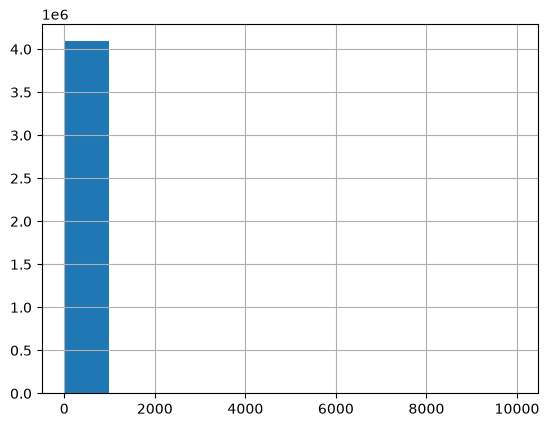

In [20]:
df['duration'].hist()

In [21]:
1000/60

16.666666666666668

In [27]:
(df['passenger_count']>5).sum()

np.int64(4557)

In [32]:
(df['total_amount']>100).sum()

np.int64(78391)

In [35]:
df.count()

VendorID                 4090836
tpep_pickup_datetime     4090836
tpep_dropoff_datetime    4090836
passenger_count          3135465
trip_distance            4090836
RatecodeID               3135465
store_and_fwd_flag       3135465
PULocationID             4090836
DOLocationID             4090836
payment_type             4090836
fare_amount              4090836
extra                    4090836
mta_tax                  4090836
tip_amount               4090836
tolls_amount             4090836
improvement_surcharge    4090836
total_amount             4090836
congestion_surcharge     3135465
Airport_fee              3135465
cbd_congestion_fee       4090836
duration                 4090836
dtype: int64

In [36]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("PandasToPySparkTutorial")
    .getOrCreate()
)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/26 23:33:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [38]:
df_raw = spark.read.parquet(file_path)

In [39]:
df_raw.printSchema()
df_raw.show(5)

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|       2| 2026-05-01 00:04:59|  2026-05-01 00:32:48|              1|         7.51|         1|                 N|         138|    

In [40]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,duration
0,2,2026-05-01 00:04:59,2026-05-01 00:32:48,1.0,7.51,1.0,N,138,37,2,...,6.00,0.5,0.00,0.0,1.0,45.40,0.0,2.0,0.00,27.816667
1,2,2026-05-01 00:37:05,2026-05-01 00:59:47,1.0,6.14,1.0,N,138,237,1,...,6.00,0.5,9.56,0.0,1.0,49.81,2.5,2.0,0.75,22.700000
2,1,2026-05-01 00:34:05,2026-05-01 00:54:02,1.0,2.40,1.0,N,249,232,1,...,4.25,0.5,3.73,0.0,1.0,28.58,2.5,0.0,0.75,19.950000
3,1,2026-05-01 00:55:07,2026-05-01 01:02:43,0.0,1.20,1.0,N,232,114,1,...,4.25,0.5,3.00,0.0,1.0,18.05,2.5,0.0,0.75,7.600000
4,7,2026-05-01 00:44:13,2026-05-01 00:44:13,2.0,0.86,1.0,N,140,237,1,...,0.00,0.5,2.44,0.0,1.0,14.64,2.5,0.0,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4090831,2,2026-05-31 23:35:12,2026-05-31 23:51:04,NaN,5.11,NaN,None,74,243,0,...,0.00,0.5,0.00,0.0,1.0,18.69,NaN,NaN,0.00,15.866667
4090832,1,2026-05-31 23:48:01,2026-06-01 00:05:57,NaN,8.80,NaN,None,129,130,0,...,0.00,0.5,0.00,0.0,1.0,33.48,NaN,NaN,0.00,17.933333
4090833,2,2026-05-31 23:48:50,2026-06-01 00:03:52,NaN,6.47,NaN,None,48,116,0,...,0.00,0.5,0.00,0.0,1.0,28.87,NaN,NaN,0.75,15.033333
4090834,2,2026-05-31 23:23:13,2026-05-31 23:38:35,NaN,2.94,NaN,None,113,256,0,...,0.00,0.5,0.00,0.0,1.0,22.95,NaN,NaN,0.75,15.366667


In [42]:
from pyspark.sql.functions import col

df_small = df_raw.select(
    col("VendorID"),
    col("trip_distance"),
    col("total_amount")
)

In [45]:
df_small.head(5)

[Row(VendorID=2, trip_distance=7.51, total_amount=45.4),
 Row(VendorID=2, trip_distance=6.14, total_amount=49.81),
 Row(VendorID=1, trip_distance=2.4, total_amount=28.58),
 Row(VendorID=1, trip_distance=1.2, total_amount=18.05),
 Row(VendorID=7, trip_distance=0.86, total_amount=14.64)]

In [46]:
df["trip_distance"].dtypes

dtype('float64')

In [49]:
df2 = df_raw.select(
    col("trip_distance").cast("double"),
    col("VendorID").cast("int")
)

In [50]:
df2.head(5)

[Row(trip_distance=7.51, VendorID=2),
 Row(trip_distance=6.14, VendorID=2),
 Row(trip_distance=2.4, VendorID=1),
 Row(trip_distance=1.2, VendorID=1),
 Row(trip_distance=0.86, VendorID=7)]

In [52]:
(df['tpep_pickup_datetime'] > df['tpep_dropoff_datetime']).sum()

np.int64(0)

In [58]:
df[df['passenger_count'] <= 0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,duration
3,1,2026-05-01 00:55:07,2026-05-01 01:02:43,0.0,1.2,1.0,N,232,114,1,...,4.25,0.5,3.00,0.00,1.0,18.05,2.5,0.0,0.75,7.600000
72,1,2026-05-01 00:50:39,2026-05-01 00:50:55,0.0,0.0,1.0,N,191,191,3,...,1.00,0.5,0.00,0.00,1.0,5.50,0.0,0.0,0.00,0.266667
229,1,2026-05-01 00:08:08,2026-05-01 00:08:08,0.0,0.0,99.0,Y,114,264,1,...,0.00,0.0,0.00,0.00,0.0,14.41,0.0,0.0,0.00,0.000000
1503,1,2026-05-01 00:56:23,2026-05-01 01:06:19,0.0,2.5,1.0,N,230,236,1,...,4.25,0.5,3.00,0.00,1.0,22.25,2.5,0.0,0.75,9.933333
2693,1,2026-05-01 01:57:08,2026-05-01 02:00:28,0.0,0.5,1.0,N,246,68,1,...,4.25,0.5,2.15,0.00,1.0,13.00,2.5,0.0,0.75,3.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3133800,1,2026-05-31 23:02:28,2026-05-31 23:12:24,0.0,3.1,1.0,N,238,164,1,...,4.25,0.5,4.10,0.00,1.0,24.75,2.5,0.0,0.75,9.933333
3133801,1,2026-05-31 23:43:18,2026-05-31 23:45:17,0.0,0.8,1.0,N,229,141,1,...,4.25,0.5,1.20,0.00,1.0,12.75,2.5,0.0,0.75,1.983333
3133802,1,2026-05-31 23:52:41,2026-06-01 00:06:29,0.0,4.1,1.0,N,145,113,1,...,4.25,0.5,6.45,7.46,1.0,38.76,2.5,0.0,0.75,13.800000
3134226,1,2026-05-31 23:53:11,2026-05-31 23:59:23,0.0,1.7,1.0,N,162,141,1,...,4.25,0.5,3.00,0.00,1.0,18.05,2.5,0.0,0.75,6.200000


In [60]:
df.shape

(4090836, 21)